# Network Traffic Analysis

This notebook imports data collected by a Daphne evaluation run, analyzes
message latency and communication patterns, and visualizes results.

## 1. Load Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
# Replace '../output.csv' with the path to your CSV file
# As a reminder, please run `go run ./daphne run` to produce this file
data = pd.read_csv('../output.csv')

# Filter rows with relevant 'mark' values
data = data[data['mark'].str.startswith('Msg')]

## 2. Message Types
The following chart illustrates the relative composition of the types of
messages being transmitted on the network.


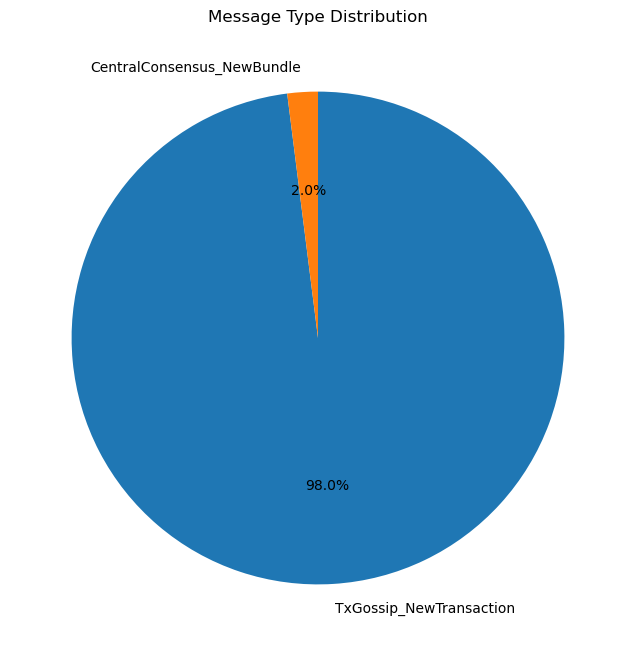

In [6]:
# Count the occurrences of each message type
type_counts = data['type'].value_counts()

# Plot pie chart
plt.figure(figsize=(8, 8))
type_counts.plot.pie(autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title('Message Type Distribution')
plt.ylabel('')
plt.show()

## 3. Message Latency

The following chart illustrates the latency between the transmission and the
reception of a message on the network.

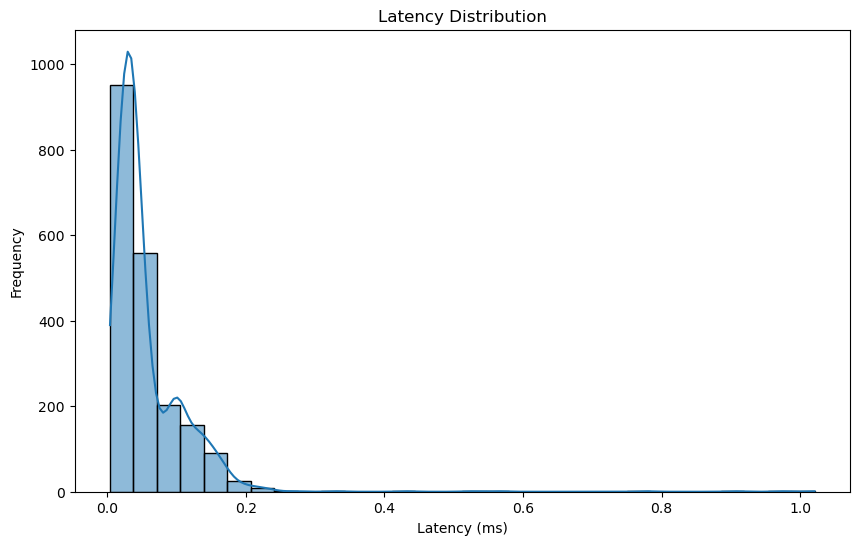

count    2.003000e+03
mean     5.645398e+04
std      6.131309e+04
min      3.940000e+03
50%      3.864500e+04
90%      1.274410e+05
95%      1.498810e+05
99%      2.037233e+05
max      1.020895e+06
Name: latency, dtype: float64

In [7]:
sent = data[data['mark'] == 'MsgSent'][['id','timestamp']]
received = data[data['mark'] == 'MsgReceived'][['id','timestamp']]

joined = pd.merge(sent, received, on='id', how='inner', suffixes=('_sent', '_received'))
joined['latency'] = joined['timestamp_received'] - joined['timestamp_sent']
latency = joined['latency']

plt.figure(figsize=(10, 6))
sns.histplot(latency/1e6, bins=30, kde=True)
plt.title('Latency Distribution')
plt.xlabel('Latency (ms)')
plt.ylabel('Frequency')
plt.show()

# Latency statistics
latency.describe(percentiles=[0.5, 0.9, 0.95, 0.99])

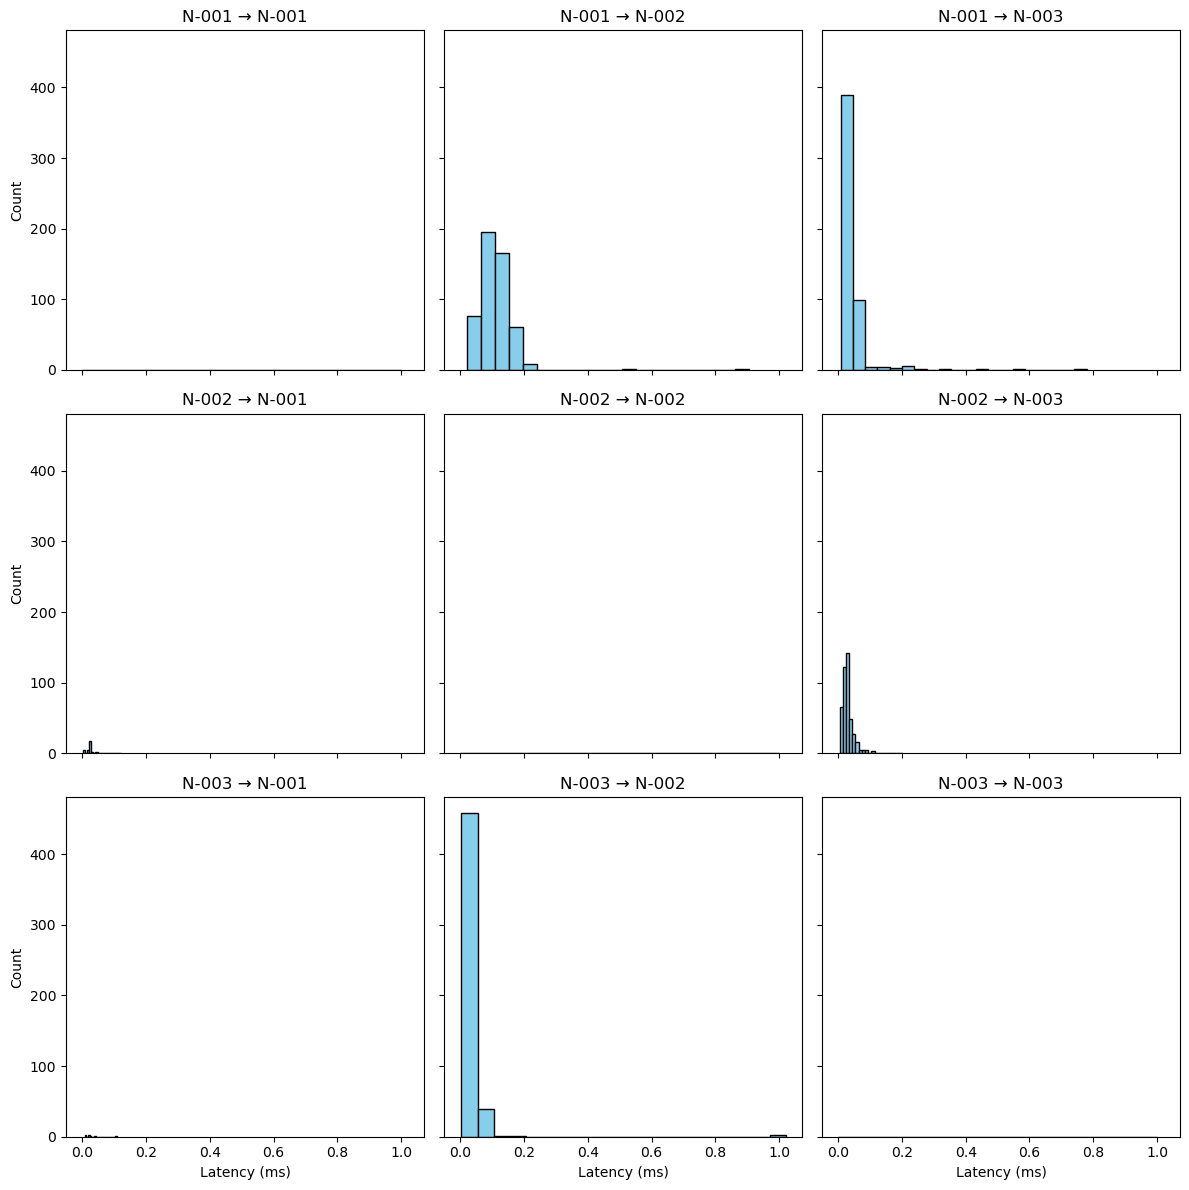

In [8]:
nodes = sorted(set(data['from']).union(set(data['to'])))

if len(nodes) > 5:
    print(f"WARNING: Detected {len(nodes)} nodes, limiting to first 5 nodes for clarity.")
    nodes = nodes[:5]  # Limit to first 5 nodes for clarity

n = len(nodes)

fig, axes = plt.subplots(n, n, figsize=(4*n, 4*n), sharex=True, sharey=True)
for i, sender in enumerate(nodes):
    for j, receiver in enumerate(nodes):
        ax = axes[i, j]
        mask = (data['from'] == sender) & (data['to'] == receiver)
        ids = set(data[mask & (data['mark'] == 'MsgSent')]['id'])
        latencies = joined[joined['id'].isin(ids)]['latency'] / 1e6  # ms
        ax.hist(latencies, bins=20, color='skyblue', edgecolor='black')
        ax.set_title(f"{sender} → {receiver}")
        if i == n-1:
            ax.set_xlabel('Latency (ms)')
        if j == 0:
            ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

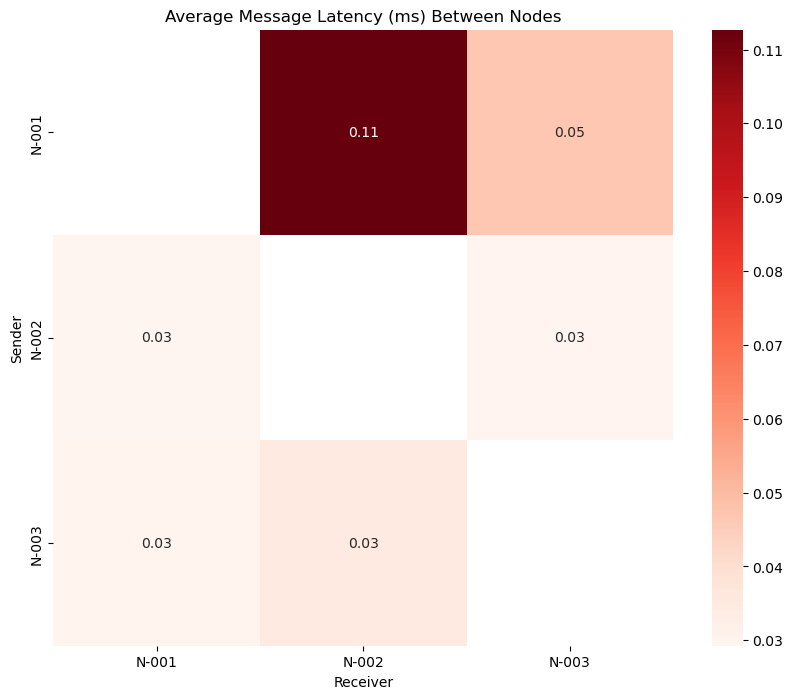

In [9]:
# Group by sender ('from') and receiver ('to'), calculate mean latency
pair_latency = \
    pd.merge(joined, data[['id', 'from', 'to']], on='id', how='left')\
        .groupby(['from', 'to'])['latency'].mean()\
            .reset_index()

plt.figure(figsize=(10, 8))
pivot = pair_latency.pivot(index='from', columns='to', values='latency') / 1e6  # convert to ms
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Reds")
plt.title('Average Message Latency (ms) Between Nodes')
plt.xlabel('Receiver')
plt.ylabel('Sender')
plt.show()

## 4. Communication Patterns
The following chart illustrates the total number of messages being transferred
between various nodes on the network.

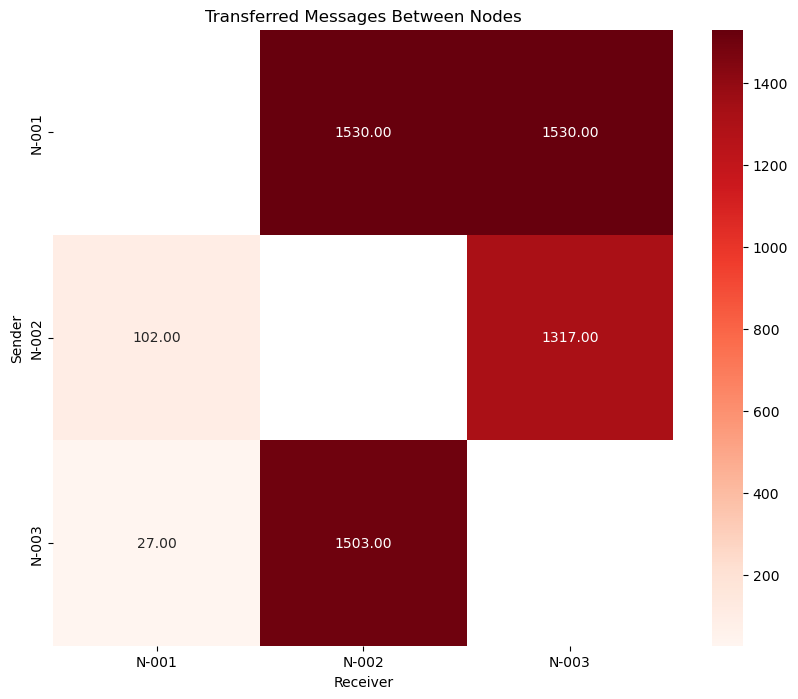

In [10]:
# Group by sender ('from') and receiver ('to'), calculate number of messages
pair_latency = \
    pd.merge(joined, data[['id', 'from', 'to']], on='id', how='left')\
        .groupby(['from', 'to']).count()\
            .reset_index()

plt.figure(figsize=(10, 8))
pivot = pair_latency.pivot(index='from', columns='to', values='latency')
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Reds")
plt.title('Transferred Messages Between Nodes')
plt.xlabel('Receiver')
plt.ylabel('Sender')
plt.show()